In [2]:
using SpeedyWeather

In [3]:
spectral_grid = SpectralGrid()
output = NetCDFOutput(spectral_grid)

NetCDFOutput{Field{Float32, 1, Vector{Float32}, FullGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}}}
├ status: inactive/uninitialized
├ write restart file: true (if active)
├ interpolator: AnvilInterpolator{Float32, RingGrids.GridGeometry{OctahedralGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}, Vector{Float32}, Vector{Int64}}, RingGrids.AnvilLocator{Float32, Vector{Float32}, Vector{Int64}}}
├ path: output.nc (overwrite=false)
├ frequency: 21600 seconds
└┐ variables:
 ├ v: meridional wind [m/s]
 ├ u: zonal wind [m/s]
 └ vor: relative vorticity [s^-1]

In [4]:
model = PrimitiveWetModel(spectral_grid)
model.output

NetCDFOutput{Field{Float32, 1, Vector{Float32}, FullGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}}}
├ status: inactive/uninitialized
├ write restart file: true (if active)
├ interpolator: AnvilInterpolator{Float32, RingGrids.GridGeometry{OctahedralGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}, Vector{Float32}, Vector{Int64}}, RingGrids.AnvilLocator{Float32, Vector{Float32}, Vector{Int64}}}
├ path: output.nc (overwrite=false)
├ frequency: 21600 seconds
└┐ variables:
 ├ v: meridional wind [m/s]
 ├ humid: specific humidity [kg/kg]
 ├ temp: temperature [degC]
 ├ u: zonal wind [m/s]
 ├ mslp: mean sea-level pressure [hPa]
 └ vor: relative vorticity [s^-1]

In [11]:
model.land

LandModel <: SpeedyWeather.AbstractWetLand
├ spectral_grid: SpectralGrid{CPU{KernelAbstractions.CPU}, Spectrum{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}, OctahedralGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}}
├ geometry: LandGeometry{Vector{Float32}}
├ thermodynamics: LandThermodynamics{Float32}
├ temperature: LandBucketTemperature{Float32}
├ soil_moisture: LandBucketMoisture{Float32}
├ snow: SnowModel{Float32}
├ vegetation: VegetationClimatology{Float32, Field{Float32, 1, Vector{Float32}, OctahedralGaussianGrid{CPU{KernelAbstractions.CPU}, Vector{UnitRange{Int64}}, Vector{Int64}}}}
└ rivers: Nothing

In [5]:
simulation = initialize!(model)

Simulation{PrimitiveWetModel}
├ prognostic_variables::PrognosticVariables{...}
├ diagnostic_variables::DiagnosticVariables{...}
└ model::PrimitiveWetModel{...}

In [7]:
run!(simulation, period=Day(30), output=true)

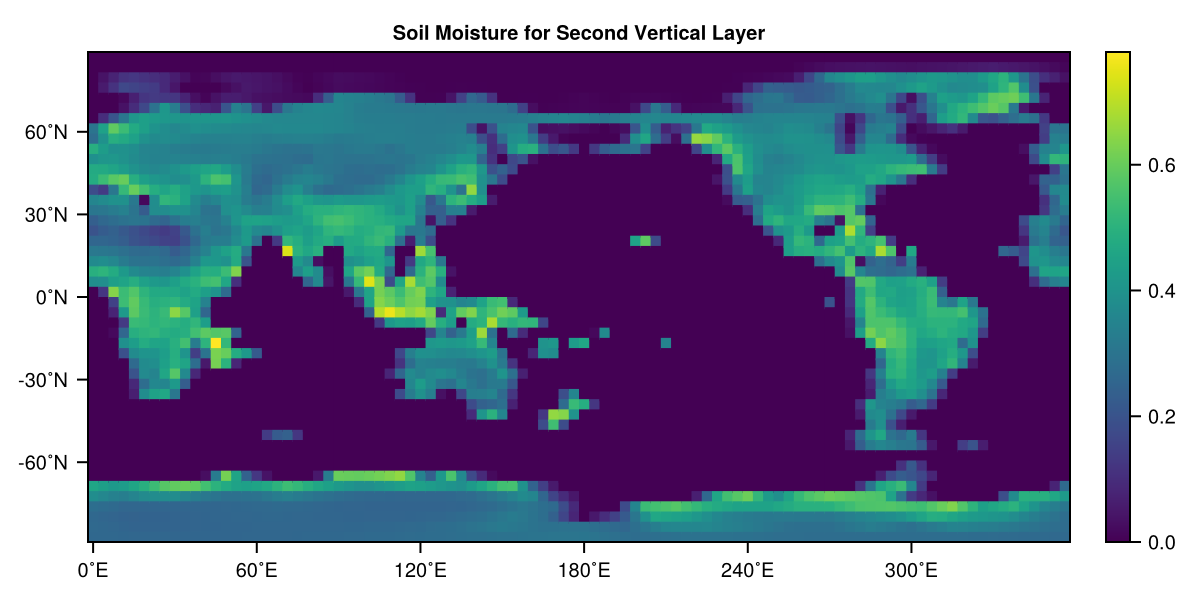

In [40]:
using GLMakie

soil_moisture = simulation.prognostic_variables.land.soil_moisture[:, 2]
GLMakie.heatmap(soil_moisture, title="Soil Moisture for Second Vertical Layer")

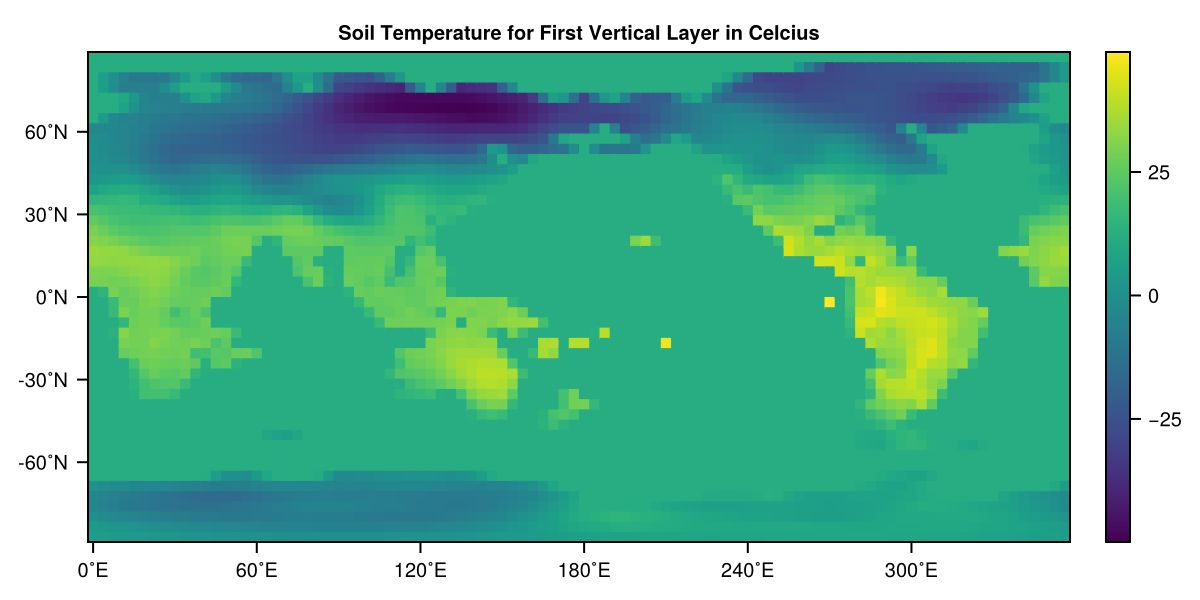

In [80]:
surface_temp = simulation.prognostic_variables.land.soil_temperature[:,1]
surface_temp_C = surface_temp .- 273.15
GLMakie.heatmap(surface_temp_C, title="Soil Temperature for First Vertical Layer in Celcius")

In [176]:
# Checking if each grid cell is habitable or not

# Take every cell and compute if it is between -25 and 25 degrees
# If yes, plot green, if no, plot red

# Habitability fraction for surface soil temperature
hab_mask_st = (surface_temp_C .> -25.0) .& (surface_temp_C .< 25.0) 
hab_frac_st = ( sum(hab_mask_st.data) / length(hab_mask_st.data) ) * 100

# Habitability fraction for surface soil moisture
sm = simulation.prognostic_variables.land.soil_moisture[:, 1]
hab_mask_sm = sm .>= 0.9
hab_frac_sm = ( sum(hab_mask_sm.data) / length(hab_mask_sm.data) ) * 100

print(hab_frac_sm, hab_frac_st)

1.483585858585858679.67171717171718

In [161]:
typeof(hab_mask)

isnan_vec = isnan.(surface_temp_C)

green = RGB(0.0, 0.7, 0.0)
red   = RGB(0.8, 0.0, 0.0)
grey  = RGB(0.7, 0.7, 0.7)

colours = ifelse.(isnan_vec, grey, ifelse.(hab_mask, green, red))


In [81]:
# using NCDatasets
# run_folder = model.output.run_folder
# ds = NCDataset("$run_folder/output.nc")

In [82]:
# ds["temp"].attrib

# lon = ds["lon"][:]
# lat = ds["lat"][:]
# T = ds["temp"]

# tidx = 120
# kidx = 7

# # Get the slice as a plain Array
# A = Array(T[:, :, kidx, tidx])

# close(ds)

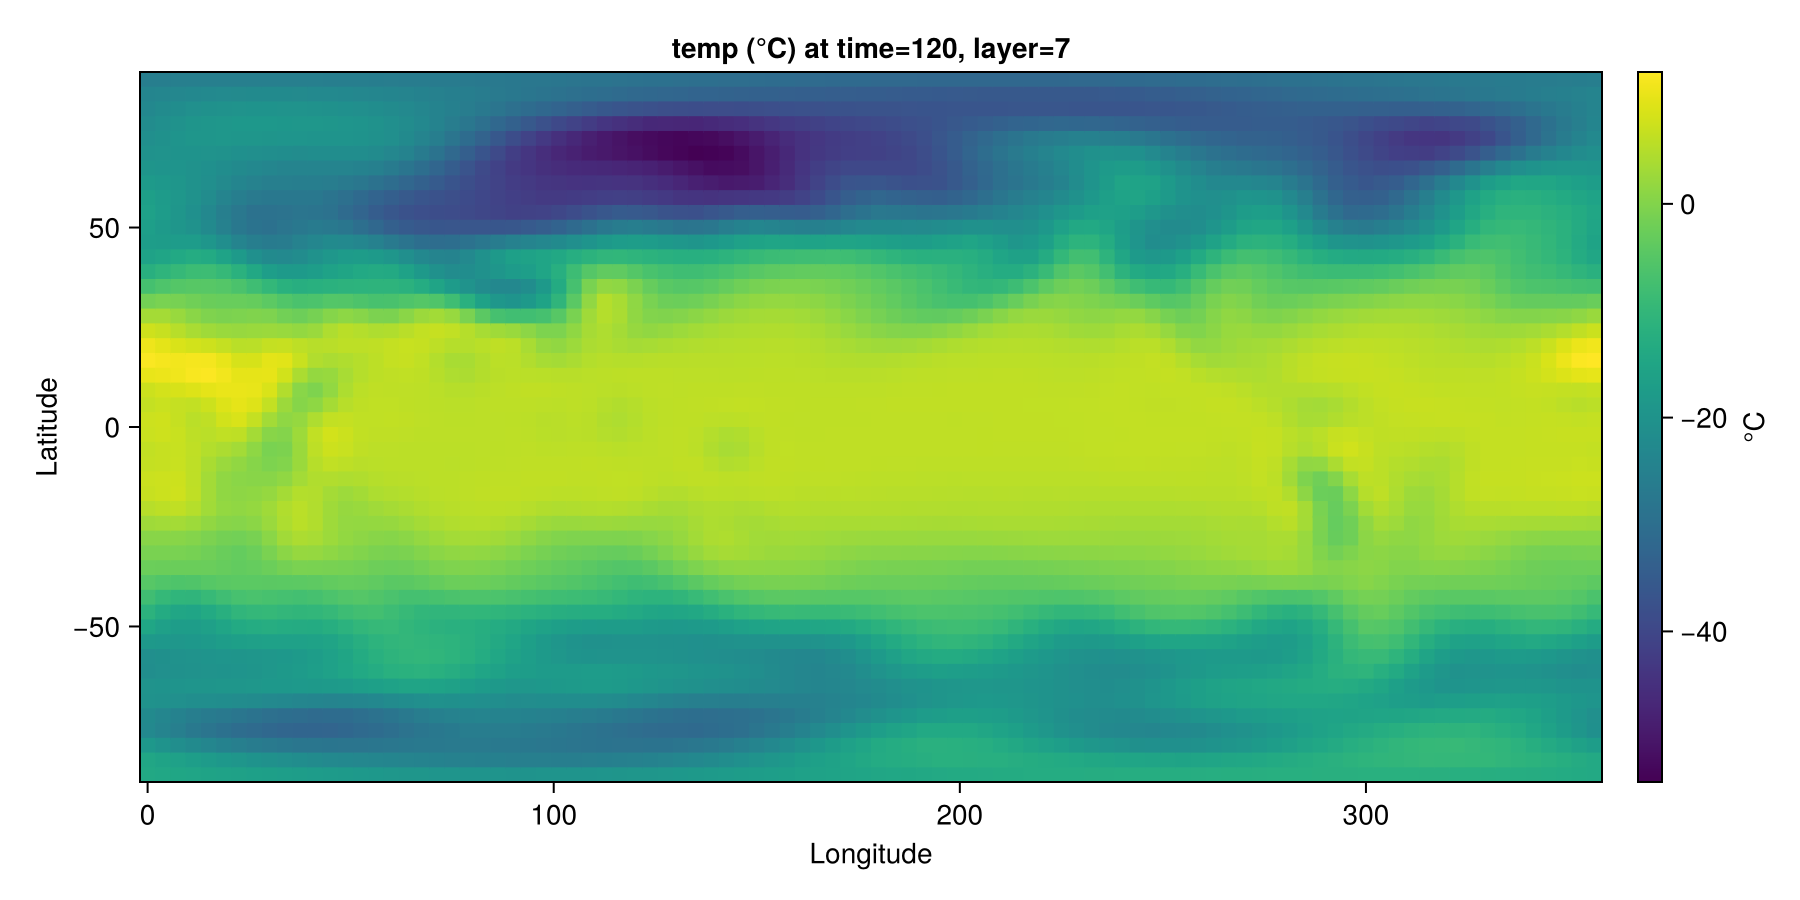

In [83]:
# fig = Figure(size=(900,450))
# ax = Axis(fig[1,1], xlabel="Longitude", ylabel="Latitude",
#           title="temp (°C) at time=$tidx, layer=$kidx")

# hm = GLMakie.heatmap!(ax, lon, lat, A)   # <-- coordinates drive the axes
# Colorbar(fig[1,2], hm, label="°C")

fig